## 1.Importing Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import(
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [34]:
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Load Dataset

In [35]:
df=pd.read_csv(r"C:\Users\danie\Downloads\finaccess2024_datasprint.csv")

In [36]:
df.head()
df

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20866,Wajir,Rural,Female,36-45,8,"""None """,Married/Living with partner,6600,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,One correct,2,Awareness,Without Disability
20867,Nairobi City,Urban,Female,18-25,4,"""Some secondary""",Married/Living with partner,10000,Usage,Non-usage,...,Yes,Yes,Yes,No,No,Worsened,Two correct,3,Affordability,Without Disability
20868,Embu,Rural,Male,Above 55,6,"""Some primary """,Widowed,6000,Non-usage,Non-usage,...,No,Yes,Yes,No,No,Stayed the same,None correct,4,NaN,Without Disability
20869,Taita-Taveta,Urban,Female,26-35,7,"""Primary completed""",Single/Never Married,13000,Usage,Non-usage,...,No,Yes,No,No,No,Stayed the same,All correct,6,Affordability,Without Disability


## 3.Inspecting the Dataset

In [37]:
#Checks rows and Columns
df.shape



(20871, 28)

In [38]:
#Checks column names,data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20871 entries, 0 to 20870
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   county                 20871 non-null  str  
 1   location_type          20871 non-null  str  
 2   Sex                    20871 non-null  str  
 3   Age                    20871 non-null  str  
 4   household_size         20871 non-null  int64
 5   education_level        20871 non-null  str  
 6   marital_status         20871 non-null  str  
 7   monthly_income         20871 non-null  int64
 8   Savings_formal         20871 non-null  str  
 9   Savings_informal       20871 non-null  str  
 10  Loan_formal            20871 non-null  str  
 11  Loan_informal          20871 non-null  str  
 12  defaulted              20871 non-null  str  
 13  formal_service_use     20871 non-null  str  
 14  mobile_money_access    20871 non-null  str  
 15  barriers_mobile_money  20871 non-null  str  
 1

In [39]:
##Check Statistics
df.describe()

,household_size,monthly_income,prodsum1
count,20871.000000,20871.000000,20871.000000
mean,4.215946,9702.774280,3.936563
std,2.512658,15423.366592,3.227992
min,1.000000,100.000000,0.000000
25%,2.000000,2500.000000,1.000000
50%,4.000000,5000.000000,3.000000
75%,6.000000,10000.000000,6.000000
max,20.000000,200000.000000,22.000000


In [40]:
##Check for missing values per column
df.isnull().sum()

county                      0
location_type               0
Sex                         0
Age                         0
household_size              0
education_level             0
marital_status              0
monthly_income              0
Savings_formal              0
Savings_informal            0
Loan_formal                 0
Loan_informal               0
defaulted                   0
formal_service_use          0
mobile_money_access         0
barriers_mobile_money       0
mobile_ownership_1          0
experienced_shock           0
nfhi_11                     0
nfhi_12                     0
nfhi_13                     0
accessto_13k_1month         0
not_difficult               0
financial_status            0
fl_score                    0
prodsum1                    0
barriers_bank            5734
has_disability              0
dtype: int64

## 4.Data Cleaning

In [41]:
## Replace missing values
df["barriers_bank"] =(
    df["barriers_bank"].fillna("No barrier")
)
##clean education labels
df["education_level"]=(df["education_level"].astype(str).str.replace('""','',regex=False).str.strip()
                      ) 


In [42]:
df.isnull().sum()

county                   0
location_type            0
Sex                      0
Age                      0
household_size           0
education_level          0
marital_status           0
monthly_income           0
Savings_formal           0
Savings_informal         0
Loan_formal              0
Loan_informal            0
defaulted                0
formal_service_use       0
mobile_money_access      0
barriers_mobile_money    0
mobile_ownership_1       0
experienced_shock        0
nfhi_11                  0
nfhi_12                  0
nfhi_13                  0
accessto_13k_1month      0
not_difficult            0
financial_status         0
fl_score                 0
prodsum1                 0
barriers_bank            0
has_disability           0
dtype: int64

## 5.Exploratory Data Analysis

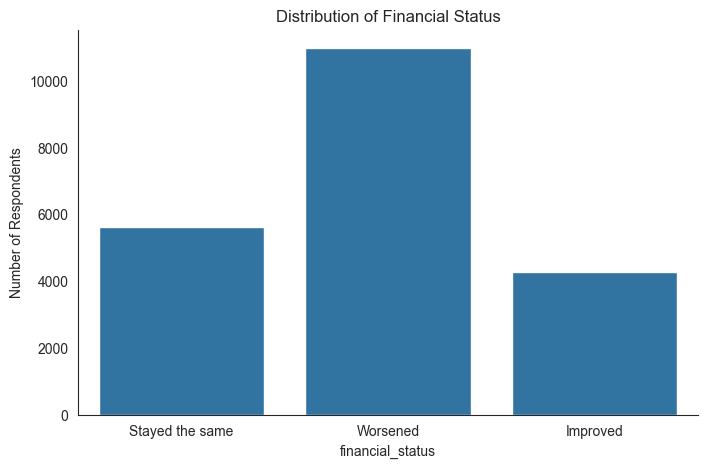

In [43]:
plt.figure(figsize=(8,5))
sns.set_style("white")
sns.countplot(
    data=df,
    x="financial_status"
)
plt.ylabel("Number of Respondents")
sns.despine(top=True)
plt.title("Distribution of Financial Status")
plt.show()

**Majority reported a worsening status**

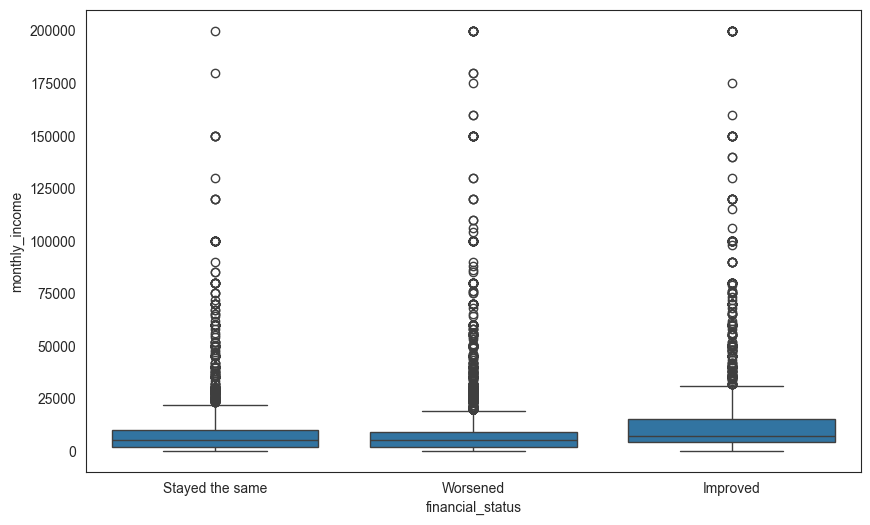

In [44]:
plt.figure(figsize=(10,6))
sns.set_style("white")
sns.boxplot(
    data=df,
    x="financial_status",
    y="monthly_income"
)
plt.show()

**The boxplot shows that respondents who reported an improved financial situation tend to have a slightly higher median monthly income compared to other groups.
However,there is significant overlap in income distributions across all categories,indicating that income alone is not a strong determinant of financial status change.
    Interestingly,even some high-income individuals report worsened financial conditions,suggesting that factors such as financial shocks,debt levels, and financial management may play a more important role than income alone.**

## 6.Data Preprocessing

In [45]:
## Separate predictors and target
x=df.drop("financial_status",
         axis=1)
y=df["financial_status"]

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
X_train,X_test,y_train,y_test=(
    train_test_split(
        x,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
        )                    
)

## 7. Encoding
--Encode categorical Variables

In [48]:
#Separating numeric columns
num_cols=["household_size","monthly_income","prodsum1"]
#Hence now everything else becomes categorical
cat_cols=[
    c
    for c in x.columns
    if c not in num_cols]
preprocessor=(
ColumnTransformer(
    transformers=[

        ("num",StandardScaler(),
         num_cols),
        ("cat",OneHotEncoder(
            handle_unknown="ignore"),
         cat_cols
        )
    ]
)
)

## 8. Model Training

In [49]:
model=Pipeline([
    (
        "prep",
        preprocessor
    ),
    (
    "clf",
        LogisticRegression(
            max_iter=3000,
            random_state=42
        ))])

###### Pipeline:
Step 1 preprocess
Step 2 train model

In [50]:
model.fit(
    X_train,
    y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

## 9.Evaluate Model

In [51]:
y_pred=model.predict(
    X_test)

##### Generate predictions

In [52]:
weighted_f1=(
    f1_score(
    y_test,
    y_pred,
    average="weighted"))
print("Weighted F1:",
     round(
         weighted_f1,
         4
     ))
print(
    classification_report(
        y_test,
        y_pred
    ))

Weighted F1: 0.533
                 precision    recall  f1-score   support

       Improved       0.47      0.29      0.36       856
Stayed the same       0.48      0.22      0.31      1122
       Worsened       0.61      0.87      0.72      2197

       accuracy                           0.58      4175
      macro avg       0.52      0.46      0.46      4175
   weighted avg       0.55      0.58      0.53      4175



**Measures overall performance**

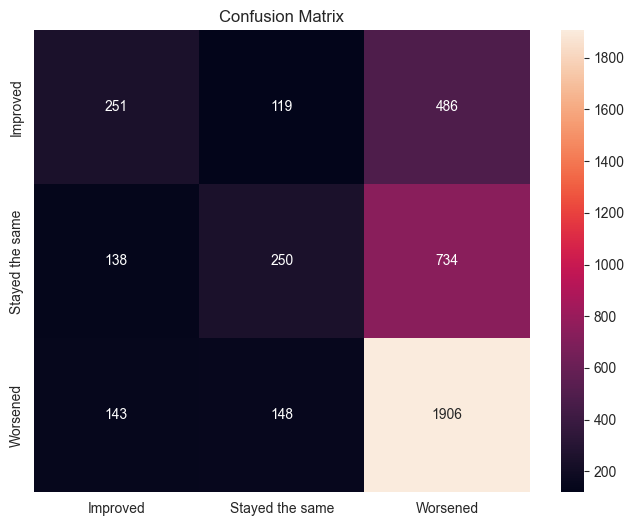

In [53]:
cm=(
    confusion_matrix(
    y_test,
    y_pred
))
plt.figure(
    figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.title("Confusion Matrix")

plt.show()

## 10.Interpretation

--Key drivers of Financial Deteroriation

In [54]:
prep=model.named_steps["prep"]
clf=model.named_steps["clf"]
feature_names=(
    prep.get_feature_names_out())
classes=(
    clf.classes_)
worsened_idx=(list(classes).index("Worsened"))
coef=(
    clf.coef_[worsened_idx]
)
importance=(
    pd.DataFrame({"feature":
                  feature_names,
                  "coef":
                  coef}))
importance=(importance.sort_values("coef",ascending=False))
importance.head(20)

,feature,coef
19,cat__county_Kisumu,0.625514
74,cat__marital_status_Don't know (DO NOT READ ...,0.484411
42,cat__county_Tana River,0.465102
9,cat__county_Garissa,0.463193
76,cat__marital_status_Refused to Answer(DO NOT R...,0.442206
10,cat__county_Homabay,0.423004
27,cat__county_Marsabit,0.396763
45,cat__county_Turkana,0.371578
8,cat__county_Embu,0.356901
62,"cat__education_level_""Other (Specify) """,0.281560


## Policy Recommendations

1. Improve Access to Emergency Savings and Financial Safety Nets

The analysis showed that most respondents reported a worsening financial situation, suggesting that many households struggle to cope with unexpected expenses and economic shocks. Expanding access to emergency savings products, community savings groups, and low-cost financial support programmes can help households build resilience and avoid falling into financial distress during difficult periods.

2. Expand Financial Literacy and Money Management Programmes

Financial outcomes are often influenced by an individual's ability to budget, save, and make informed financial decisions. The model identified demographic factors such as age and education level as important predictors of financial status. This suggests that targeted financial literacy programmes can help individuals improve financial planning, debt management, and long-term savings behaviour, particularly among vulnerable groups.

3. Reduce the Cost of Banking and Promote Affordable Digital Financial Services

One of the strongest predictors of financial deterioration was the presence of banking barriers, particularly high charges and product pricing. Policymakers and financial institutions should work together to lower transaction costs, simplify account requirements, and promote affordable digital banking and mobile money solutions. Reducing these barriers can increase financial inclusion and encourage greater use of formal financial services.

4. Provide Targeted Support to High-Risk Regions and Vulnerable Populations

The model highlighted several counties as having a higher likelihood of respondents reporting a worsened financial situation. This indicates that financial challenges are not evenly distributed across the country. Government agencies and development partners should implement targeted interventions in these regions, such as employment programmes, business support initiatives, and social protection measures, to address local economic vulnerabilities.

5. Strengthen Debt Counselling and Financial Recovery Services

Many households experiencing financial deterioration may rely on borrowing to manage expenses, increasing their risk of over-indebtedness. Expanding access to debt counselling services and financial advisory programmes can help individuals manage existing debt, improve repayment strategies, and regain financial stability.

Concluding Statement

Overall, the findings suggest that financial deterioration is influenced by a combination of demographic characteristics, regional disparities, income constraints, and barriers to accessing financial services. Therefore, policies should focus on improving financial inclusion, reducing banking costs, strengthening financial education, and providing targeted support to vulnerable households and regions to improve financial well-being across Kenya.


### Improve Model

In [55]:
RandomForestClassifier(
    n_estimators=300)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_score = f1_score(
    y_test,
    rf_pred,
    average="weighted"
)

print("Random Forest F1 Score:", rf_score)

## Comparing the two Models
1.Logistic Regression
F1 Score(weighted):0.533
Performs slightly better than Random Forest in this dataset
Assumes a mostly linear relationship between features and the target
Easier to interpret using model coefficients.

2.Random Forest Classifier
F1 Score(weighted):0.5224
Slightly lower perfomance compared to Logistic Regression
Captures non-linear relationships using multiple decision trees
Less interpretable but more flexible in complex datasets

In [ ]:
#importances=(
    #model.named_steps[
        #"model"
       # ]
    ##.coef_[0]
#)
#print(importances)

In [ ]:
##feature_names = model.named_steps["prep"].get_feature_names_out()

#coefficients = model.named_steps["model"].coef_[0]

#for feature, coef in zip(feature_names, coefficients):
    #print(feature, coef)

In [ ]:
print(model.named_steps)

{'prep': ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['household_size', 'monthly_income',
                                  'prodsum1']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['county', 'location_type', 'Sex', 'Age',
                                  'education_level', 'marital_status',
                                  'Savings_formal', 'Savings_informal',
                                  'Loan_formal', 'Loan_informal', 'defaulted',
                                  'formal_service_use', 'mobile_money_access',
                                  'barriers_mobile_money', 'mobile_ownership_1',
                                  'experienced_shock', 'nfhi_11', 'nfhi_12',
                                  'nfhi_13', 'accessto_13k_1month',
                                  'not_difficult', 'fl_score', 'barriers_bank',
                                  'has_disability'])]

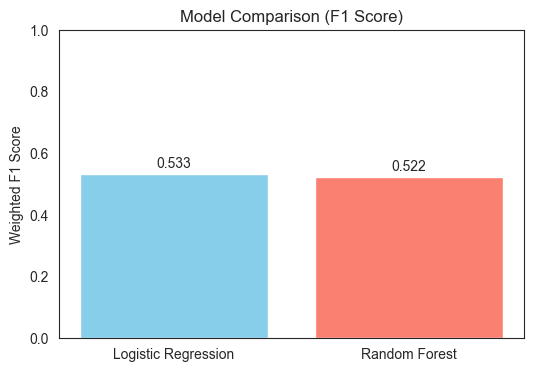

In [ ]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest"]
scores = [0.533, 0.5224]

plt.figure(figsize=(6,4))
bars = plt.bar(models, scores, color=["skyblue", "salmon"])

plt.title("Model Comparison (F1 Score)")
plt.ylabel("Weighted F1 Score")
plt.ylim(0, 1)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3),
             ha="center", va="bottom")

plt.show()

**This visualization compares the performance of Logistic Regression and Random Forest using the weighted F1 score.We observe that Logistic Regression slightly outperforms Random Forest on this dataset,although the difference is small.This suggests that simpler linear models are sufficient for capturing the underlying patterns in the data**